In [1]:
import sys
sys.path.append('../')

# Adding concentrated NH3 to CuSO4(aq)

In [2]:
import warnings
import os
# remove full file path from warning messages
def custom_formatwarning(message, category, filename, lineno, line=None):
    if "ipykernel" in filename:
        filename = "notebook_cell"
    else:
        filename = os.path.basename(filename)

    return warnings._formatwarning_orig(message, category, filename, lineno, line)

warnings.formatwarning = custom_formatwarning

In [3]:
import numpy as np
import eq_solver

In [4]:
s = eq_solver.System.from_yaml('060.yaml')
s.stoichiometry_matrix_as_df()

,H+,Cu2+,SO4^2-,NH3
H+,1.0,0.0,-0.00,0.0
OH-,-1.0,-0.0,0.00,-0.0
Cu2+,0.0,1.0,-0.00,0.0
SO4^2-,0.0,0.0,1.00,-0.0
HSO4^-,1.0,0.0,1.00,0.0
NH4+,1.0,0.0,0.00,1.0
NH3,-0.0,0.0,0.00,1.0
Cu(OH)2(s),-2.0,1.0,0.00,-0.0
[Cu(OH)]+,-1.0,1.0,-0.00,0.0
[Cu(OH)2]aq,-2.0,1.0,0.00,-0.0


In [5]:
c_cuso4 = 0.05
c_nh3_list = np.logspace(-5, 0.5, 100)
cond_list = [eq_solver.Conditions.from_dict(s, {'copper': c_cuso4, 'sulfate': c_cuso4, 'ammonia': c_nh3}) for c_nh3 in c_nh3_list]
results = eq_solver.solve_for_conditions(s, cond_list)

solver.py:119: RuntimeWarning: overflow encountered in power
solver.py:127: RuntimeWarning: invalid value encountered in matmul
solver.py:119: RuntimeWarning: overflow encountered in power
solver.py:127: RuntimeWarning: invalid value encountered in matmul
solver.py:119: RuntimeWarning: overflow encountered in power
solver.py:127: RuntimeWarning: invalid value encountered in matmul
solver.py:119: RuntimeWarning: overflow encountered in power
solver.py:127: RuntimeWarning: invalid value encountered in matmul
solver.py:151: RuntimeWarning: invalid value encountered in scalar subtract


In [6]:
eq_solver.get_summary(results).loc[0,:]

cond.total.copper       5.000000e-02
cond.total.sulfate      5.000000e-02
cond.total.ammonia      1.000000e-05
sol.rmse                4.196249e-17
sol.retries             0.000000e+00
sol.nfev                9.200000e+01
pH                      4.208820e+00
ionic strength          1.090812e-01
c_total.proton          1.567330e-04
c_total.copper          4.989551e-02
c_total.sulfate         4.997388e-02
c_total.ammonia         1.000000e-05
c.H+                    7.955092e-05
c.OH-                   2.081063e-10
c.Cu2+                  2.724213e-02
c.SO4^2-                2.725331e-02
c.HSO4^-                7.730433e-05
c.NH4+                  9.979525e-06
c.NH3                   7.152612e-11
c.Cu(OH)2(s)            1.882876e-34
c.[Cu(OH)]+             6.541322e-06
c.[Cu(OH)2]aq           1.640667e-10
c.[Cu(OH)3]-            1.711218e-17
c.[Cu(OH)4]2-           7.421999e-26
c.[Cu2(OH)2]2+          1.779350e-06
c.[Cu3(OH)4]2+          2.919320e-10
c.[CuSO4]               2.264326e-02
c

Text(0.5, 0.98, 'Distribution of ammonia')

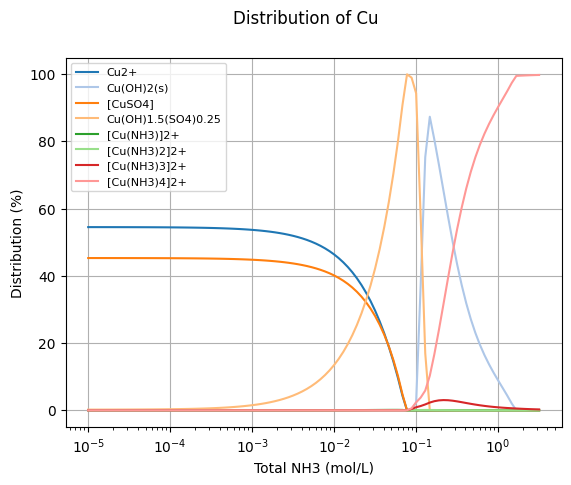

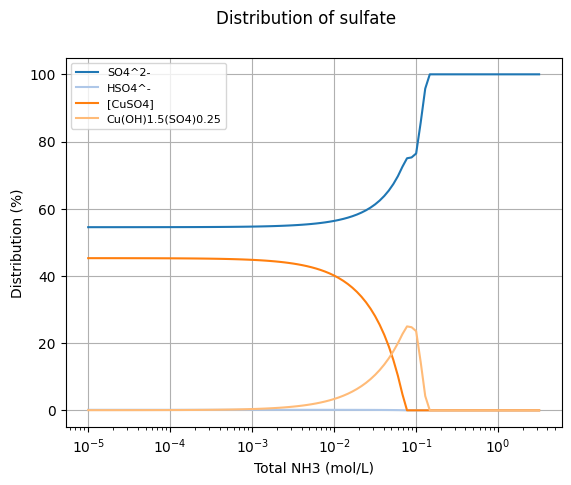

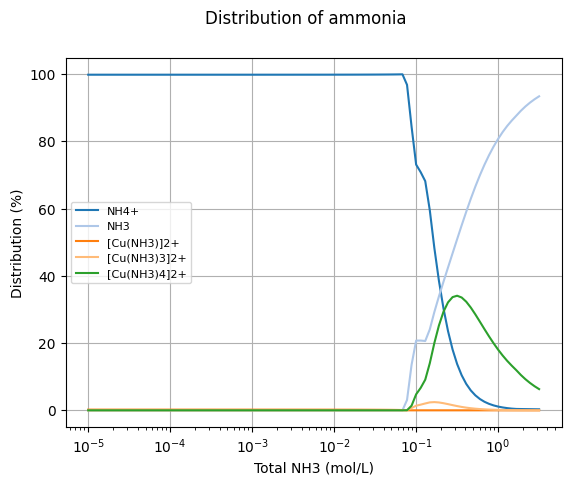

In [7]:
import matplotlib.pyplot as plt
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.get_cmap("tab20").colors)

df_dist = eq_solver.get_distribution(results, 'copper', relative=True)
cols = [c for c in df_dist.columns if 'Cu' in c if (df_dist[c].max() > 0.1)]
df_dist.plot(x='cond.total.ammonia', y=cols)
plt.xlabel('Total NH3 (mol/L)')
plt.ylabel('Distribution (%)')
plt.xscale('log')
plt.grid()
plt.legend(fontsize=8)
plt.suptitle('Distribution of Cu')

df_dist = eq_solver.get_distribution(results, 'sulfate', relative=True)
cols = [c for c in df_dist.columns if 'SO' in c if (df_dist[c].max() > 0.1)]
df_dist.plot(x='cond.total.ammonia', y=cols)
plt.xlabel('Total NH3 (mol/L)')
plt.ylabel('Distribution (%)')
plt.xscale('log')
plt.legend(fontsize=8)
plt.grid()
plt.suptitle('Distribution of sulfate')

df_dist = eq_solver.get_distribution(results, 'ammonia', relative=True)
cols = [c for c in df_dist.columns if 'NH' in c if (df_dist[c].max() > 0.1)]
df_dist.plot(x='cond.total.ammonia', y=cols)
plt.xlabel('Total NH3 (mol/L)')
plt.ylabel('Distribution (%)')
plt.xscale('log')
plt.legend(fontsize=8)
plt.grid()
plt.suptitle('Distribution of ammonia')

<Figure size 640x480 with 0 Axes>

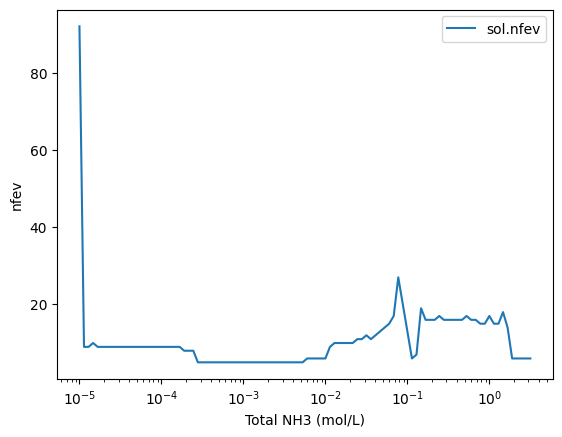

<Figure size 640x480 with 0 Axes>

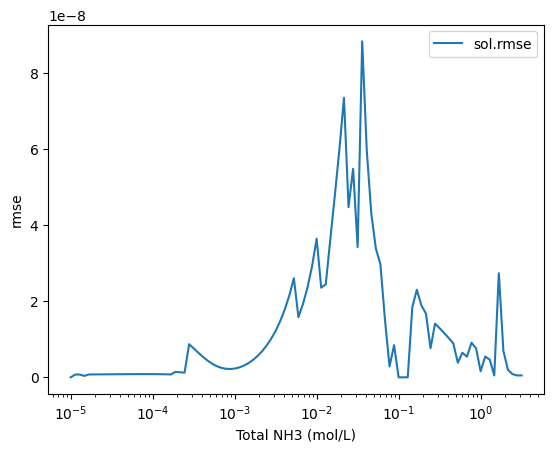

In [8]:
plt.figure()
df_dist.plot(x='cond.total.ammonia', y='sol.nfev')
plt.xlabel('Total NH3 (mol/L)')
plt.ylabel('nfev')
plt.xscale('log')

plt.figure()
df_dist.plot(x='cond.total.ammonia', y='sol.rmse')
plt.xlabel('Total NH3 (mol/L)')
plt.ylabel('rmse')
plt.xscale('log')

